# Healthcare Insurance Cost Analysis & Prediction
This notebook explores a healthcare insurance dataset to understand the factors affecting insurance charges and builds predictive models to estimate insurance costs based on individual characteristics.
This analysis investigates how individual characteristics and lifestyle factors influence medical insurance costs. The dataset includes:

- **Age**: Age of the insured individual  
- **Sex**: Male or Female  
- **BMI**: Body Mass Index  
- **Children**: Number of dependents  
- **Smoker**: Yes/No  
- **Region**: Geographical region  
- **Charges**: Insurance costs  

Key questions addressed in this analysis:

- Does age increase insurance costs?  
- Do smokers pay more than non-smokers?  
- Does BMI influence insurance costs?  
- How do gender, children, and region impact charges?  
- Which factors most strongly predict charges?

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
import os
print(os.getcwd())

C:\Users\Munga\HealthInsurance


In [28]:
df=pd.read_csv(r"C:\Users\Munga\HealthInsurance\insurance.csv")


In [29]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [30]:
df.shape

(1338, 7)

In [31]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [33]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [34]:
df.duplicated().sum()

1

## Exploratory Data Analysis (EDA) 

We begin by exploring the dataset distributions and relationships between features.

In [35]:
df.agg(mean_age=("age" ,"mean") ,median_age=("age","median"))

,age
mean_age,39.207025
median_age,39.000000


In [36]:
df.groupby("sex").agg(mean_age=("age" ,"mean") ,median_age=("age","median"),children_number=("children" , "sum")).reset_index()

,sex,mean_age,median_age,children_number
0,female,39.503021,40.0,711
1,male,38.917160,39.0,754


In [37]:
filt = (df["bmi"] > 24.9) & (df["bmi"] < 29.9)
df.loc[filt] ["bmi"].value_counts()

bmi
28.310    9
28.880    8
25.800    7
27.645    7
25.460    7
         ..
26.070    1
29.100    1
29.545    1
27.075    1
27.800    1
Name: count, Length: 125, dtype: int64

In [38]:
filt=df["bmi"]>29.9
df.loc[filt]["bmi"].value_counts()

bmi
32.300    13
30.800     8
34.100     8
30.875     8
31.350     8
          ..
37.145     1
39.520     1
38.190     1
37.700     1
30.970     1
Name: count, Length: 296, dtype: int64

In [39]:
df.groupby("sex").agg(mean_charges=("charges" ,"mean") ,mean_age=("age","median"),children_number=("children" , "sum"),bmi_range=("bmi" ,"mean")).reset_index()

,sex,mean_charges,mean_age,children_number,bmi_range
0,female,12569.578844,40.0,711,30.377749
1,male,13956.751178,39.0,754,30.943129


In [48]:
df["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [65]:
df.groupby("children")["charges"].mean()

children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64

In [51]:
df.groupby("smoker")["charges"].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

In [47]:
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [46]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [58]:
df.groupby("region")["charges"].mean().sort_values()

region
southwest    12346.937377
northwest    12417.575374
northeast    13406.384516
southeast    14735.411438
Name: charges, dtype: float64

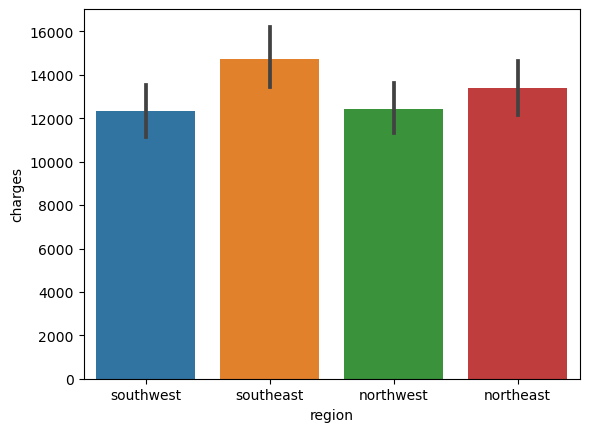

In [66]:
sns.barplot(df,x="region" ,y="charges")
plt.show()

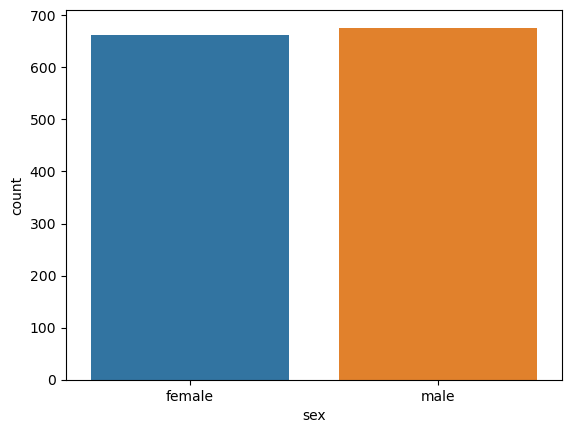

In [40]:
sns.countplot(df,x="sex")
plt.show()

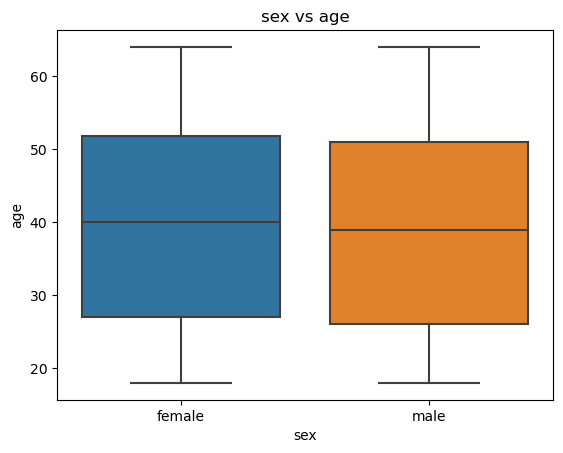

In [45]:
sns.boxplot(df,x="sex" ,y="age")
plt.title("sex vs age")
plt.show()

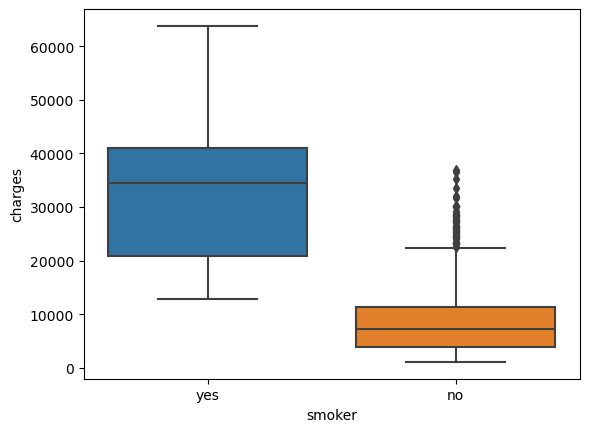

In [55]:
sns.boxplot(df,x="smoker" ,y="charges")
plt.show()

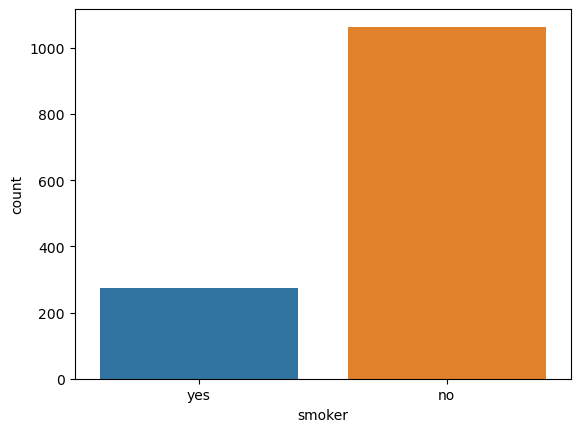

In [54]:
sns.countplot(df,x="smoker")
plt.show()

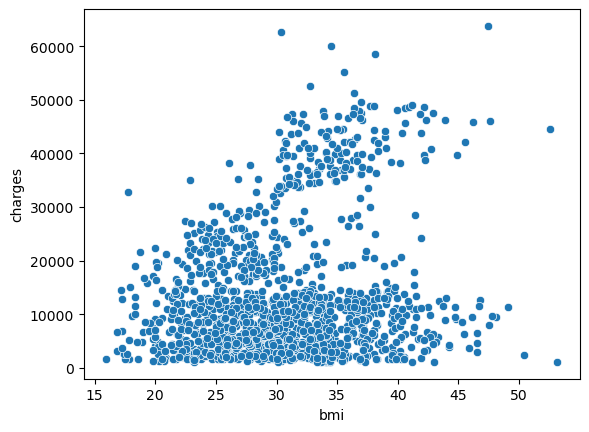

In [60]:
sns.scatterplot(df,x="bmi" ,y="charges")
plt.show()

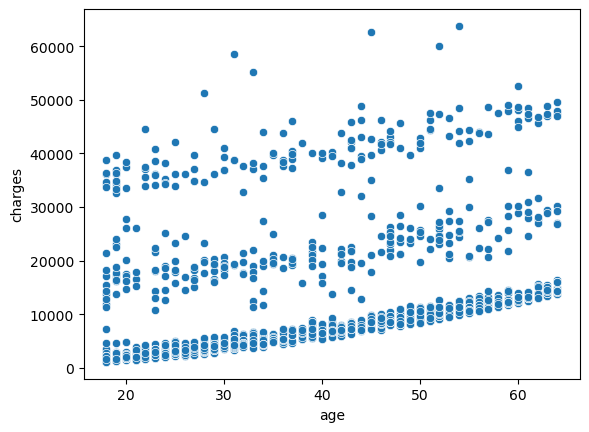

In [56]:
sns.scatterplot(df,x="age" ,y="charges")
plt.show()

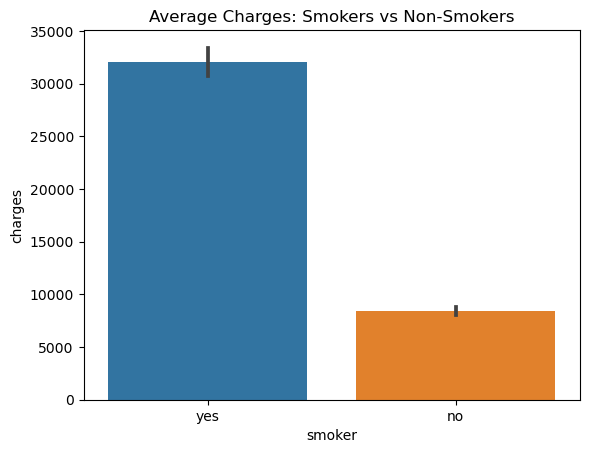

In [59]:
sns.barplot(data=df, x="smoker", y="charges")
plt.title("Average Charges: Smokers vs Non-Smokers")
plt.show()

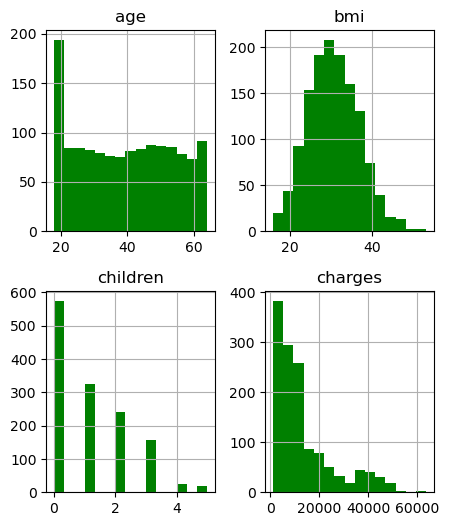

In [64]:
df.hist(figsize=(5,6) ,bins=15 ,color="green")
plt.show()

In [67]:
df["bmi_category"]=pd.cut(df["bmi"],
                          bins=[0,18.5,25,30,100],
                          labels=["Underweight","Normal","Overweight","Obese"]
                         )

In [69]:
df.groupby(["smoker","bmi_category"])["charges"].mean()

C:\Users\Munga\AppData\Local\Temp\ipykernel_14700\423253253.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["smoker","bmi_category"])["charges"].mean()


smoker  bmi_category
no      Underweight      5485.056800
        Normal           7734.650116
        Overweight       8226.088675
        Obese            8853.277294
yes     Underweight     18809.824980
        Normal          19942.223641
        Overweight      22491.182935
        Obese           41692.808992
Name: charges, dtype: float64

C:\Users\Munga\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\Munga\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


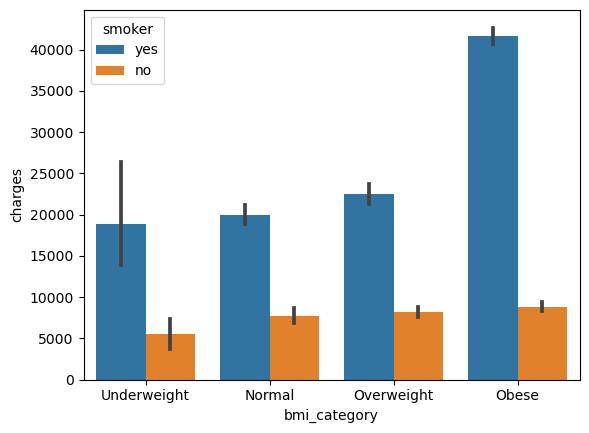

In [72]:
sns.barplot(df,x="bmi_category" , y="charges" ,hue="smoker")
plt.show()

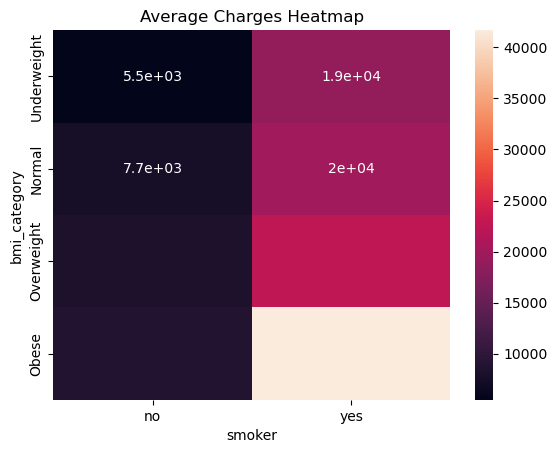

In [73]:
pivot = df.pivot_table(
    values="charges",
    index="bmi_category",
    columns="smoker",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True)

plt.title("Average Charges Heatmap")
plt.show()

# Modeling 

We trained four regression models to predict insurance charges.

In [79]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
df_encoded=pd.get_dummies(df,drop_first=True)

In [77]:
x=df_encoded.drop("charges",axis=1)
y=df_encoded["charges"]

In [78]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
linearreg=LinearRegression()
linearreg.fit(x_train,y_train)
y_linearreg_pred=linearreg.predict(x_test)
print("Linear Regression R²:", r2_score(y_test, y_linearreg_pred))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_linearreg_pred)))
                                   


Linear Regression R²: 0.7814227070041221
Linear Regression RMSE: 5825.276600344035


In [82]:
from sklearn.tree import DecisionTreeRegressor
decisiontree=DecisionTreeRegressor(random_state=42)
decisiontree.fit(x_train,y_train)
y_decisiontree_pred=decisiontree.predict(x_test)
print("Decision Tree R²:", r2_score(y_test, y_decisiontree_pred))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_decisiontree_pred)))


Decision Tree R²: 0.7292533043072615
Decision Tree RMSE: 6483.292455372259


In [83]:
from sklearn.ensemble import RandomForestRegressor
randomforest=RandomForestRegressor(random_state=42)
randomforest.fit(x_train,y_train)
y_randomforest_pred=randomforest.predict(x_test)
print("Random Forest R²:", r2_score(y_test, y_randomforest_pred))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_randomforest_pred)))


Random Forest R²: 0.8682092380827259
Random Forest RMSE: 4523.31168614226


In [84]:
from sklearn.ensemble import GradientBoostingRegressor
gradientboost=GradientBoostingRegressor(random_state=42)
gradientboost.fit(x_train,y_train)
y_gradientboost_pred=gradientboost.predict(x_test)
print("Gradient Boosting R²:", r2_score(y_test, y_gradientboost_pred))
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, y_gradientboost_pred)))


Gradient Boosting R²: 0.8815099549590578
Gradient Boosting RMSE: 4288.989296676943


# Model Evaluation 

We evaluated models using R², RMSE, and MAE:

In [85]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Store predictions for each model
models = {
    "Linear Regression":y_linearreg_pred,
    "Decision Tree": y_decisiontree_pred,
    "Random Forest": y_randomforest_pred,
    "Gradient Boosting": y_gradientboost_pred
}

# Evaluate each model
results = []
for name, pred in models.items():
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    results.append({"Model": name, "R²": r2, "RMSE": rmse, "MAE": mae})

# Convert to DataFrame for easy comparison
import pandas as pd
results_df = pd.DataFrame(results).sort_values(by="R²", ascending=False)
print(results_df)

               Model        R²         RMSE          MAE
3  Gradient Boosting  0.881510  4288.989297  2423.594281
2      Random Forest  0.868209  4523.311686  2532.906621
0  Linear Regression  0.781423  5825.276600  4311.331174
1      Decision Tree  0.729253  6483.292455  3057.443044


# Conclusions & Insights 

Gradient Boosting is the most accurate model (R² ≈ 0.88, RMSE ≈ 4,289, MAE ≈ 2,424).

Smoking status, age, and BMI are the key drivers of insurance costs.

Random Forest performs similarly but is slightly less accurate.

Linear Regression is interpretable and useful for reports, even if it is less accurate.

Decision Tree alone overfits and is less reliable.

Business Insight: Insurance companies can use these findings to estimate premiums, identify high-risk groups, and design targeted interventions.

In [86]:
corr=df_encoded.corr()
corr

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
age,1.000000,0.109272,0.042469,0.299008,-0.020856,-0.025019,-0.000407,-0.011642,0.010016,-0.074252,-0.017373,0.086764
bmi,0.109272,1.000000,0.012759,0.198341,0.046371,0.003750,-0.135996,0.270025,-0.006205,-0.592223,-0.317016,0.799404
children,0.042469,0.012759,1.000000,0.067998,0.017163,0.007673,0.024806,-0.023066,0.021914,0.010840,-0.020039,0.011283
charges,0.299008,0.198341,0.067998,1.000000,0.057292,0.787251,-0.039905,0.073982,-0.043210,-0.105577,-0.119542,0.199683
sex_male,-0.020856,0.046371,0.017163,0.057292,1.000000,0.076185,-0.011156,0.017117,-0.004184,-0.024666,-0.019861,0.044347
smoker_yes,-0.025019,0.003750,0.007673,0.787251,0.076185,1.000000,-0.036945,0.068498,-0.036945,0.018383,-0.016541,-0.001381
region_northwest,-0.000407,-0.135996,0.024806,-0.039905,-0.011156,-0.036945,1.000000,-0.346265,-0.320829,0.037700,0.050934,-0.081139
region_southeast,-0.011642,0.270025,-0.023066,0.073982,0.017117,0.068498,-0.346265,1.000000,-0.346265,-0.091814,-0.092712,0.172247
region_southwest,0.010016,-0.006205,0.021914,-0.043210,-0.004184,-0.036945,-0.320829,-0.346265,1.000000,-0.027423,0.027853,-0.000853
bmi_category_Normal,-0.074252,-0.592223,0.010840,-0.105577,-0.024666,0.018383,0.037700,-0.091814,-0.027423,1.000000,-0.287063,-0.475767


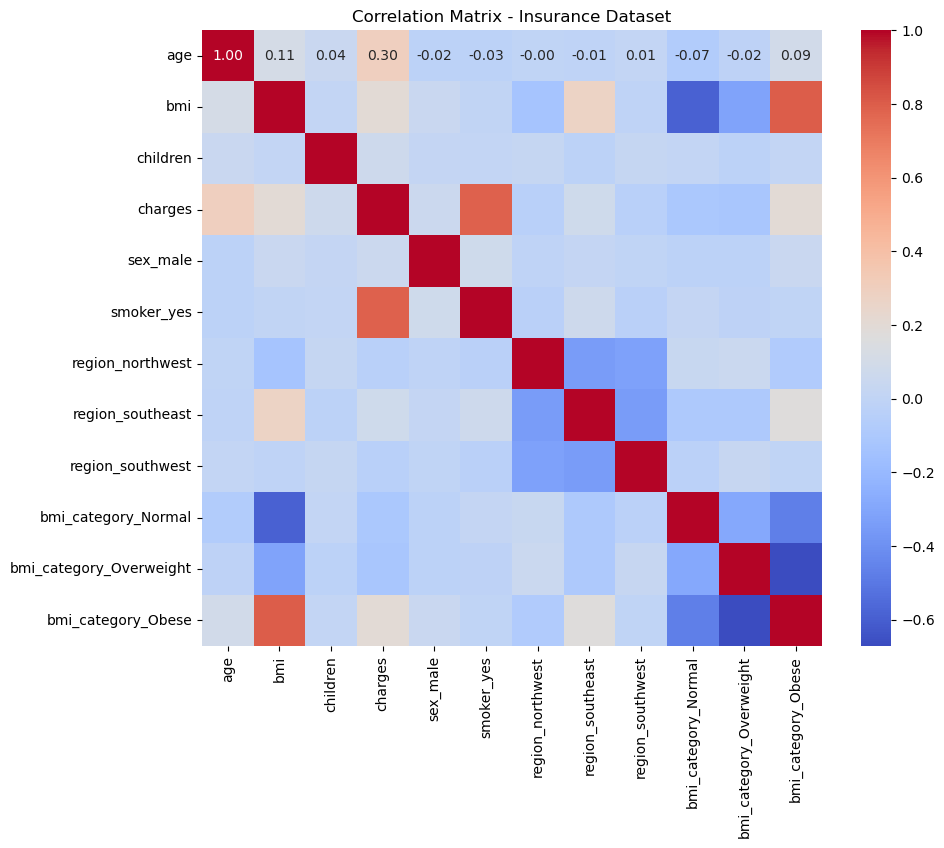

In [87]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Insurance Dataset")
plt.show()